In [10]:
import torch

In [11]:
from torch import nn
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad = True,
                                                dtype = torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                                requires_grad = True,
                                                dtype = torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [12]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [13]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [14]:
with torch.inference_mode():
    X_test = torch.linspace(0, 1, 10, dtype=torch.float32)
    y_preds = model_0(X_test)

y_preds

tensor([0.1288, 0.1662, 0.2036, 0.2410, 0.2784, 0.3159, 0.3533, 0.3907, 0.4281,
        0.4655])

In [16]:
y = 0.7 * X_test + 0.3
y_test = y.to(dtype=torch.float32)
y_test

tensor([0.3000, 0.3778, 0.4556, 0.5333, 0.6111, 0.6889, 0.7667, 0.8444, 0.9222,
        1.0000])

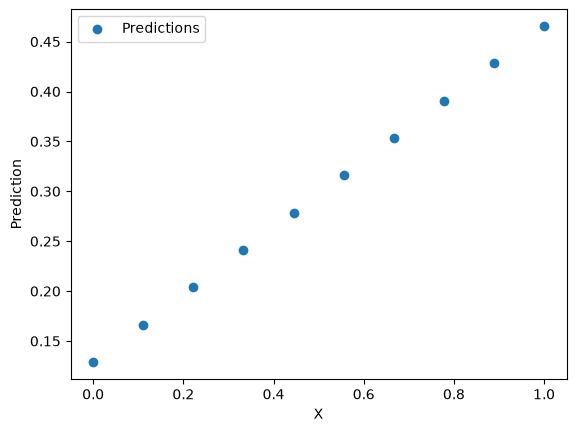

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_prediction(predictions: torch.Tensor) -> None:
    plt.scatter(
        X_test.detach().cpu().tolist(),
        predictions.detach().cpu().tolist(),
        label="Predictions"
    )
    plt.xlabel("X")
    plt.ylabel("Prediction")
    plt.legend()
    plt.show()

plot_prediction(y_preds)

In [49]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params= model_0.parameters() , lr = .0001) #params contain parameter we want to initialize

In [50]:
epochs = 100

for epoch in range(epochs):

    model_0.train()

    X_train = X_test
    y_train = 0.7 * X_train + 0.3

    # 1. Forward pass
    y_pred = model_0(X_train.clone())

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Update model
    optimizer.step()

    model_0.eval()

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 0.0008184671169146895
Epoch: 10 | Loss: 0.00011480748798931018
Epoch: 20 | Loss: 5.613267421722412e-05
Epoch: 30 | Loss: 6.048977229511365e-05
Epoch: 40 | Loss: 6.048977229511365e-05
Epoch: 50 | Loss: 6.048977229511365e-05
Epoch: 60 | Loss: 6.048977229511365e-05
Epoch: 70 | Loss: 6.048977229511365e-05
Epoch: 80 | Loss: 6.048977229511365e-05
Epoch: 90 | Loss: 6.048977229511365e-05


In [28]:
with torch.inference_mode():
    y_pred_new = model_0(X_test)

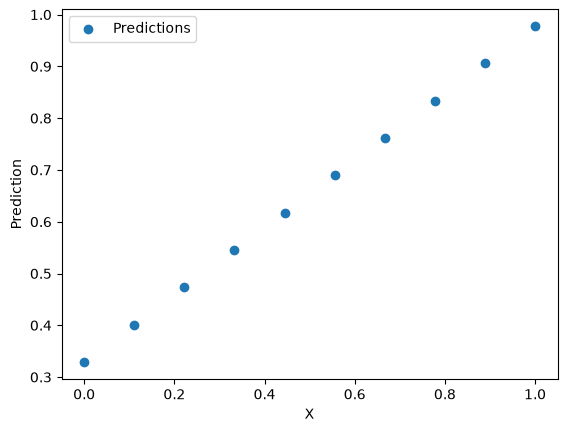

In [21]:
plot_prediction(predictions = y_pred_new)

In [22]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6489])), ('bias', tensor([0.3288]))])

In [23]:
epochs = 100

#training
for epoch in range(epochs):
    model_0.train()
    # Create training data from the existing input tensor
    X_train = X_test
    y_train = 0.7 * X_train + 0.3

    # Clone the inference tensor to create a normal tensor usable by autograd
    y_pred = model_0(X_train.clone())
    loss = loss_fn(y_pred, y_train)
    print(f"Loss: {loss}")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)
        y_test = 0.7 * X_test + 0.3
        test_loss = loss_fn(test_pred, y_test)

    if epoch%10 == 0:
        print(f"Epoch: {epoch} | loss: {loss} | Test Loss: {test_loss}")
        print(model_0.state_dict())



Loss: 0.014276569709181786
Epoch: 0 | loss: 0.014276569709181786 | Test Loss: 0.013728216290473938
OrderedDict({'weights': tensor([0.6506]), 'bias': tensor([0.3268])})
Loss: 0.013728216290473938
Loss: 0.013135826215147972
Loss: 0.01249364297837019
Loss: 0.011995101347565651
Loss: 0.01131732203066349
Loss: 0.010796114802360535
Loss: 0.010176584124565125
Loss: 0.00956155639141798
Loss: 0.009035852737724781
Loss: 0.008358070626854897
Epoch: 10 | loss: 0.008358070626854897 | Test Loss: 0.007864025421440601
OrderedDict({'weights': tensor([0.6717]), 'bias': tensor([0.3148])})
Loss: 0.007864025421440601
Loss: 0.007217335514724255
Loss: 0.006629487965255976
Loss: 0.006076595280319452
Loss: 0.0053988248109817505
Loss: 0.00493195652961731
Loss: 0.004258081316947937
Loss: 0.0036973953247070312
Loss: 0.003117325948551297
Loss: 0.002462828066200018
Epoch: 20 | loss: 0.002462828066200018 | Test Loss: 0.0021414547227323055
OrderedDict({'weights': tensor([0.6939]), 'bias': tensor([0.3048])})
Loss: 0.0

In [38]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.001
)

In [39]:
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):

    # Training
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X_train.clone())

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Update parameters
    optimizer.step()

    # Testing
    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss.item():.6f} | "
            f"Test loss: {test_loss.item():.6f}"
        )

Epoch: 0 | Loss: 0.007654 | Test loss: 0.006404
Epoch: 10 | Loss: 0.001193 | Test loss: 0.001139
Epoch: 20 | Loss: 0.000601 | Test loss: 0.000552
Epoch: 30 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 40 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 50 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 60 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 70 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 80 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 90 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 100 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 110 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 120 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 130 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 140 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 150 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 160 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 170 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 180 | Loss: 0.000432 | Test loss: 0.000818
Epoch: 190 | Loss: 0.000432 | Test loss: 0.000818


In [51]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7000])), ('bias', tensor([0.3001]))])

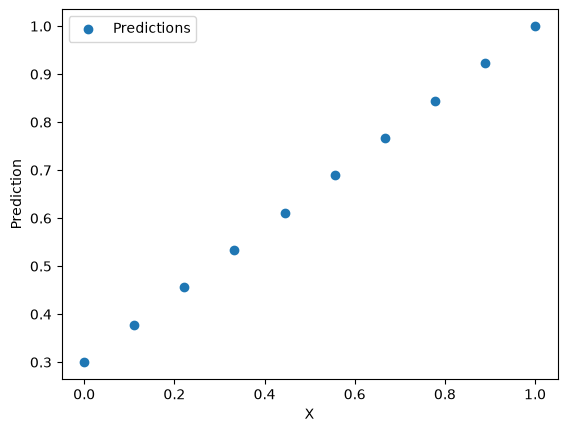

In [53]:
plot_prediction(y_test)